In [1]:
from benchmark_pipeline.generator.features import *
from benchmark_pipeline.loader.osm_loaders import load_pois, load_area, load_streets
from benchmark_pipeline.generator.template_question.semantic.generetor_qsemantic import make_questions_semantic
from benchmark_pipeline.config import FEATURES
from benchmark_pipeline.generator.template_question.composite.generator_qcomposite import make_question_composite

register_path = "/Users/sese/Documents/code/Gseek/demo_data/"

In [2]:
df_osm = load_pois()
df_street = load_streets()
df_area = load_area()

/Users/sese/Documents/code/benchmark_pipeline/benchmark_pipeline/loader/osm_extractor.py:130: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois["geometry"] = pois.geometry.centroid


In [ ]:
list_template = ['make_question_area_border',
                 'make_question_area_inside', 'make_question_area_direction',
                 'make_question_point_between', 'make_question_point_near_cardinal',
                 'make_question_point_near_metric', 'make_question_point_near',
                 'make_question_point_towards', 'make_question_street_along',
                 'make_question_street_cross']
"""
"""
#'make_question_area_outside', 'make_question_street_opposite_side',

"\n['make_question_area_border',\n                 'make_question_area_inside', 'make_question_area_direction',\n                 'make_question_point_between', 'make_question_point_near_cardinal',\n                 'make_question_point_near_metric', 'make_question_point_near',\n                 'make_question_point_towards', 'make_question_street_along',\n                 'make_question_street_cross']\n"

In [54]:
%load_ext autoreload
%autoreload 2

#df_question = make_questions_semantic(df_osm, features=FEATURES)
df_question = make_question_composite(
        df_osm, 
        df_area,
        df_street, 
        nb_q_by_temp=100, 
        nb_q_by_feat=100, 
        feature_cols=FEATURES,
        seed=42,
        list_template=list_template,
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
%load_ext autoreload
%autoreload 2

from benchmark_pipeline.generator.targets.mask_anchors import add_anchors_mask
from benchmark_pipeline.generator.targets.ellypses import add_ellypse
from gseek.models.sentence_encoder import SentenceEncoder

sentence_model = SentenceEncoder()
df_question = add_anchors_mask(df_question, sentence_model)
df_question = add_ellypse(df_question)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [71]:
%load_ext autoreload
%autoreload 2

from benchmark_pipeline.generator.template_question.register import register, BenchmarkConfig
from benchmark_pipeline.generator.template_question.composite.format_samples import format_composit_samples
from dataclasses import dataclass, asdict

df_question = df_question.rename(columns={"pois": "results_poi_id"})
conf = BenchmarkConfig(
        ratio_test = 0.1,
        ratio_features = None, #{1: 0.4, 2: 0.4, 3: 0.2}, 
        ratio_category= None,
        nb_hard = 20,
        nb_unmatches = 1,
        seed = 42,
    )
register("/Users/sese/Documents/code/Gseek/demo_data/", df_question, df_osm, conf, format_composit_samples)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import pandas as pd
df_composite = pd.read_parquet('/Users/sese/Documents/code/Gseek/demo_data/train_set.parquet')

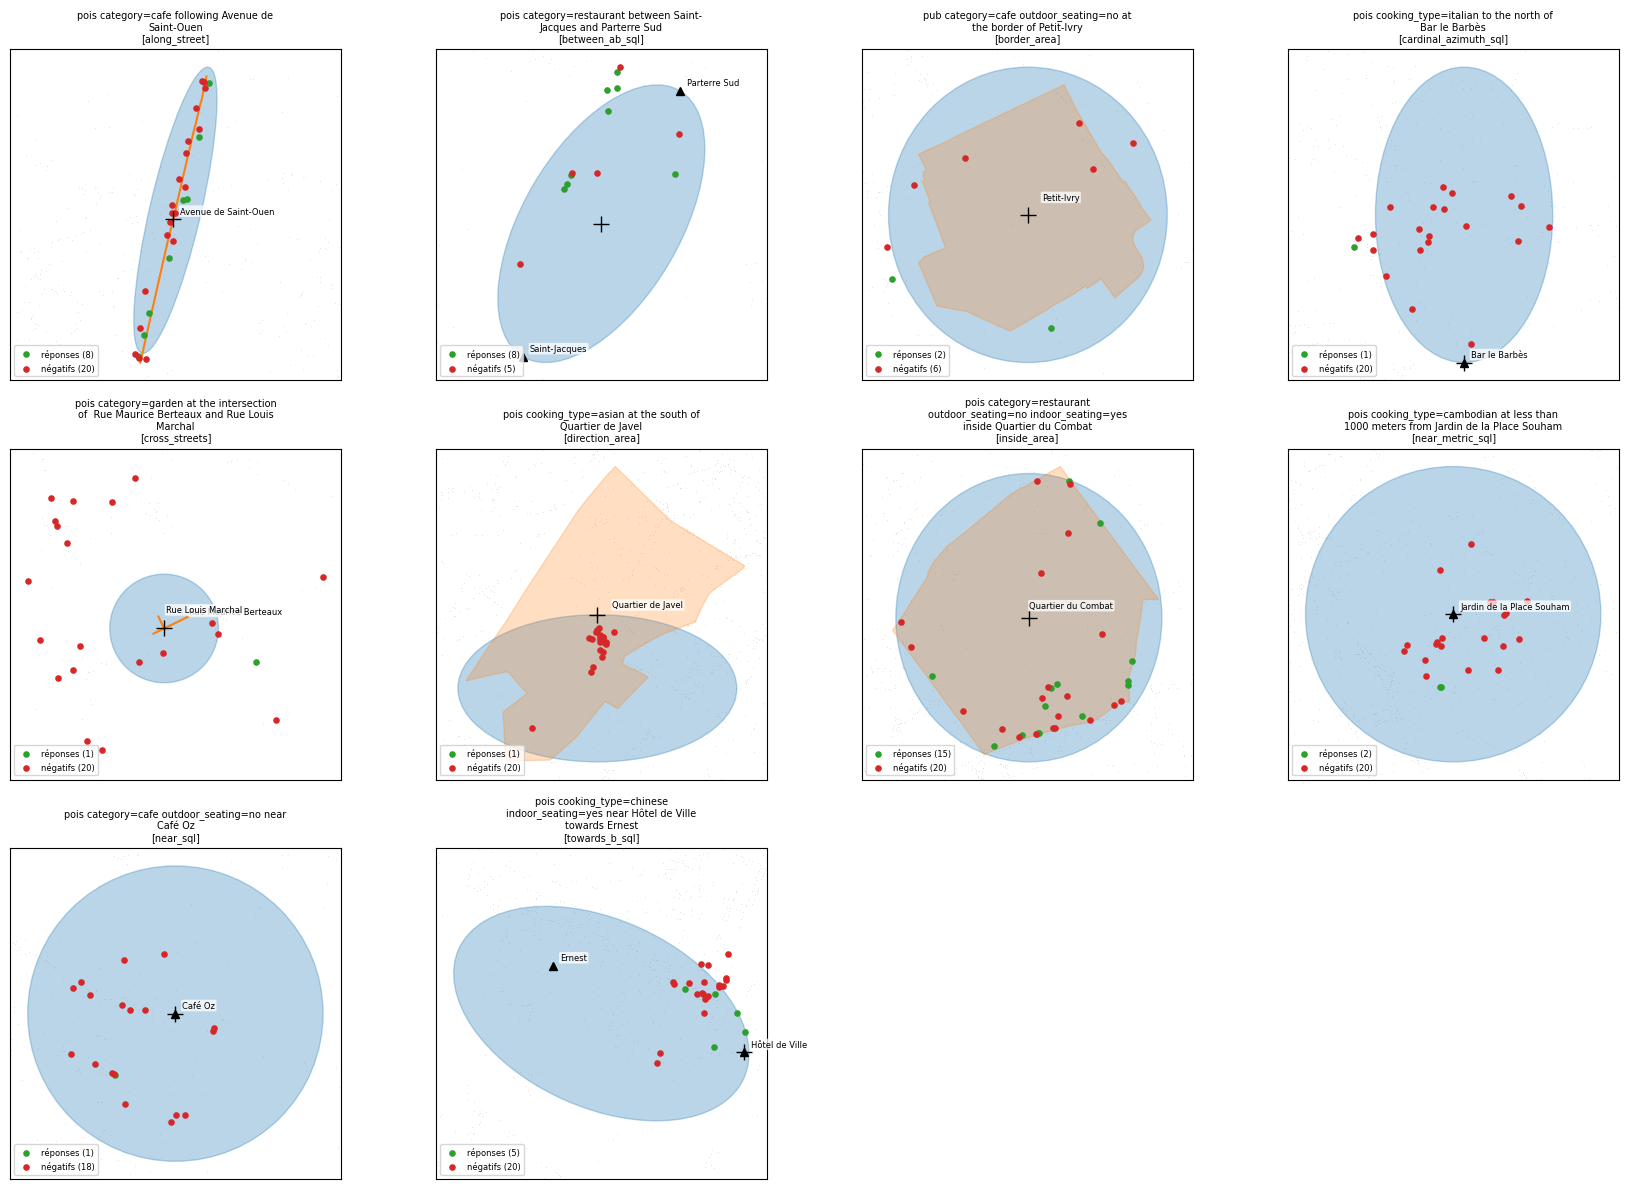

In [83]:
import math
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import shapely
from matplotlib.patches import Ellipse

from benchmark_pipeline.generator.targets.ellypses import get_ellypse
from benchmark_pipeline.generator.template_question.composite.format_samples import make_rows


ANCRES_POINTS = (("anchor_x", "anchor_y", "anchor_name"),
                 ("anchor_a_x", "anchor_a_y", "anchor_a_name"),
                 ("anchor_b_x", "anchor_b_y", "anchor_b_name"),
                 )
ANCRES_GEOMETRIES = (("area_geometry", "area_name"),
                     ("street_geometry", "street_name"),
                     ("street_a_geometry", "street_a_name"),
                     ("street_b_geometry", "street_b_name"),
                     ("poi_y_geometry", "poi_y_name"))


def point_reference(question):
    """Point auquel se rapporte le décalage de l'ellipse, qui dépend du type.

    Args:
        question: ligne de `df_question`.

    Returns:
        tuple[float, float]: coordonnées Lambert-93 du point de référence.
    """
    fonction = question["function"]
    if fonction in ("near_sql", "near_metric_sql", "cardinal_azimuth_sql", "towards_b_sql"):
        return question["anchor_x"], question["anchor_y"]
    if fonction == "between_ab_sql":
        return ((question["anchor_a_x"] + question["anchor_b_x"]) / 2,
                (question["anchor_a_y"] + question["anchor_b_y"]) / 2)
    if fonction == "along_street":
        centre = question["street_geometry"].centroid
    elif fonction == "cross_streets":
        centre = question["street_a_geometry"].intersection(question["street_b_geometry"]).centroid
    elif fonction == "opposite_side":
        centre = question["poi_y_geometry"]
    else:
        centre = question["area_geometry"].centroid
    return centre.x, centre.y


def renseigne(question, colonne):
    """Vrai si la colonne existe dans la ligne et n'y est pas vide."""
    valeur = question[colonne] if colonne in question.index else None
    # `v == v` attrape les NaN mais pas None, que produit la conversion WKT
    # ci-dessous sur toute valeur non-string.
    return valeur is not None and valeur == valeur


def tracer_geometrie(ax, geom, couleur="tab:orange"):
    """Trace une géométrie shapely, quelle que soit sa nature."""
    if geom.geom_type == "Polygon":
        ax.fill(*geom.exterior.xy, facecolor=couleur, alpha=0.25, edgecolor=couleur, zorder=2)
    elif geom.geom_type == "MultiLineString":
        for partie in geom.geoms:
            ax.plot(*partie.xy, color=couleur, linewidth=1.5, zorder=2)
    elif geom.geom_type == "LineString":
        ax.plot(*geom.xy, color=couleur, linewidth=1.5, zorder=2)
    elif geom.geom_type == "Point":
        ax.plot(geom.x, geom.y, marker="s", color=couleur, markersize=5, zorder=4)


def tracer_ancres(ax, question):
    """Place et nomme les ancres géospatiales citées par la question."""
    for colonne_x, colonne_y, colonne_nom in ANCRES_POINTS:
        if renseigne(question, colonne_x):
            ax.plot(question[colonne_x], question[colonne_y], "k^", markersize=6, zorder=5)
            etiqueter(ax, question[colonne_x], question[colonne_y], question.get(colonne_nom))
    for colonne_geom, colonne_nom in ANCRES_GEOMETRIES:
        if renseigne(question, colonne_geom):
            geom = question[colonne_geom]
            tracer_geometrie(ax, geom)
            repere = geom.representative_point()
            etiqueter(ax, repere.x, repere.y, question.get(colonne_nom))


def etiqueter(ax, x, y, nom):
    """Écrit le nom d'une ancre à côté de sa position."""
    if not isinstance(nom, str):
        return
    ax.annotate(nom, (x, y), textcoords="offset points", xytext=(5, 4), fontsize=6,
                zorder=6, bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))


def emprise_question(question, ellipse, xs_pois, ys_pois):
    """Abscisses et ordonnées de tout ce que la question concerne.

    Args:
        question: ligne de `df_question`.
        ellipse: `(centre_x, centre_y, demi_u, demi_v, inclinaison)`.
        xs_pois, ys_pois (list): coordonnees des POIs traces.

    Returns:
        tuple[list, list]: abscisses et ordonnees a garder dans le champ.
    """
    centre_x, centre_y, demi_u, demi_v, inclinaison = ellipse
    angle = math.radians(inclinaison)
    # Demi-cotes de la boite englobante d'une ellipse tournee : la projeter sur
    # les axes evite de cadrer sur son grand axe quand elle est inclinee.
    demi_x = math.hypot(demi_u * math.cos(angle), demi_v * math.sin(angle))
    demi_y = math.hypot(demi_u * math.sin(angle), demi_v * math.cos(angle))
    xs = [centre_x - demi_x, centre_x + demi_x] + list(xs_pois)
    ys = [centre_y - demi_y, centre_y + demi_y] + list(ys_pois)

    for colonne_x, colonne_y, _ in ANCRES_POINTS:
        if renseigne(question, colonne_x):
            xs.append(question[colonne_x])
            ys.append(question[colonne_y])
    for colonne_geom, _ in ANCRES_GEOMETRIES:
        if renseigne(question, colonne_geom):
            min_x, min_y, max_x, max_y = question[colonne_geom].bounds
            xs += [min_x, max_x]
            ys += [min_y, max_y]
    return xs, ys


def cadrer(ax, xs, ys, marge=0.12, cote_min=120):
    """Cadre la vue sur une emprise carree autour des coordonnees donnees.

    Args:
        ax: axes matplotlib.
        xs, ys (list): coordonnees a garder dans le champ.
        marge (float): marge ajoutee, en fraction du cote.
        cote_min (float): demi-cote plancher en metres, pour une reponse ponctuelle.
    """
    min_x, max_x, min_y, max_y = min(xs), max(xs), min(ys), max(ys)
    # Fenetre carree : l'aspect est verrouille a 1, une emprise allongee
    # laisserait des bandes vides au lieu de zoomer.
    demi = max(max((max_x - min_x), (max_y - min_y)) / 2 * (1 + marge), cote_min)
    milieu_x, milieu_y = (min_x + max_x) / 2, (min_y + max_y) / 2
    ax.set_xlim(milieu_x - demi, milieu_x + demi)
    ax.set_ylim(milieu_y - demi, milieu_y + demi)


def montrer_questions(df_question, df_osm, par_type=True, nb=10, seed=None,
                      n_hard=20, nb_unmatches=1):
    """Trace des questions sur la carte de Paris, chacune cadrée sur sa zone.

    Fond gris : tous les POIs du corpus. Vert : les réponses. Rouge : les négatifs
    difficiles. Orange et triangles noirs nommés : les ancres géospatiales citées.
    Croix noire : le point de référence de l'ellipse, tracée en bleu.

    Args:
        df_question: questions composites.
        df_osm: corpus de POI, colonnes `poi_id`, `x`, `y`.
        par_type: une question tirée par valeur de `function`. Sinon `nb` au hasard.
        nb: nombre de questions quand `par_type` est faux.
        seed: graine du tirage. `None` tire d'autres questions à chaque appel.
        n_hard: négatifs difficiles par question.
        nb_unmatches: transmis à `make_rows`.
    """
    for colonne in [c for c in df_question.columns if c.endswith("_geometry")]:
        if df_question[colonne].map(lambda v: isinstance(v, str)).any():
            df_question[colonne] = df_question[colonne].map(
                lambda v: shapely.from_wkt(v) if isinstance(v, str) else None)

    rng = np.random.default_rng(seed)
    if par_type:
        positions = np.array([rng.choice(positions_du_type)
                              for positions_du_type in df_question.groupby("function").indices.values()])
    else:
        positions = rng.choice(len(df_question), size=nb, replace=False)
    lignes = make_rows(df_question, df_osm, positions, rng, n_hard, nb_unmatches)
    coords = df_osm.set_index("poi_id")[["x", "y"]]

    colonnes = math.ceil(len(lignes) / 3)
    figure, axes = plt.subplots(3, colonnes, figsize=(4.2 * colonnes, 12))
    for ax, (_, ligne) in zip(axes.ravel(), lignes.iterrows()):
        question = df_question.iloc[ligne["index"]]
        dx, dy, demi_u, demi_v, inclinaison = get_ellypse(question)
        ref_x, ref_y = point_reference(question)

        ax.scatter(df_osm["x"], df_osm["y"], s=0.4, c="0.88", zorder=0, linewidths=0)
        ax.add_patch(Ellipse((ref_x + dx, ref_y + dy), 2 * demi_u, 2 * demi_v,
                             angle=inclinaison, facecolor="tab:blue", alpha=0.30,
                             edgecolor="tab:blue", zorder=1))
        tracer_ancres(ax, question)

        xs_pois, ys_pois = [], []
        for ids, couleur, etiquette in ((ligne["pois"], "tab:green", "réponses"),
                                        (ligne["hard_pois"], "tab:red", "négatifs")):
            points = coords.reindex(ids).dropna()
            ax.scatter(points["x"], points["y"], c=couleur, s=14, zorder=3,
                       label=f"{etiquette} ({len(points)})")
            xs_pois += list(points["x"])
            ys_pois += list(points["y"])
        ax.plot(ref_x, ref_y, "k+", markersize=11, zorder=5)

        cadrer(ax, *emprise_question(
            question, (ref_x + dx, ref_y + dy, demi_u, demi_v, inclinaison), xs_pois, ys_pois))
        # Sans aspect égal, une ellipse n'est plus une ellipse.
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("\n".join(textwrap.wrap(ligne["question"], 42)) + f"\n[{question['function']}]",
                     fontsize=7)
        ax.legend(fontsize=6, loc="lower left")

    for ax in axes.ravel()[len(lignes):]:
        ax.axis("off")
    figure.tight_layout()
    plt.show()


montrer_questions(df_question, df_osm, par_type=True)
